In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Age, Cabin** and **Embarked** have missing values. **Cabin** is missing for most rows so its not very useful as is. **Age** is important so we'll fill it instead of dropping it.





In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df["Survived"].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


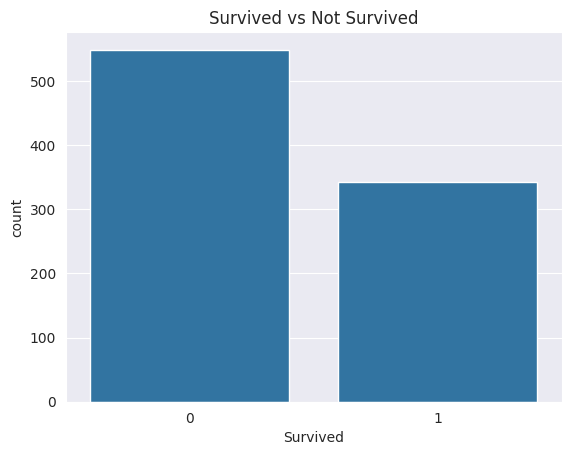

In [10]:
sns.countplot(x="Survived", data=df)
plt.title("Survived vs Not Survived")
plt.show()

In [11]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


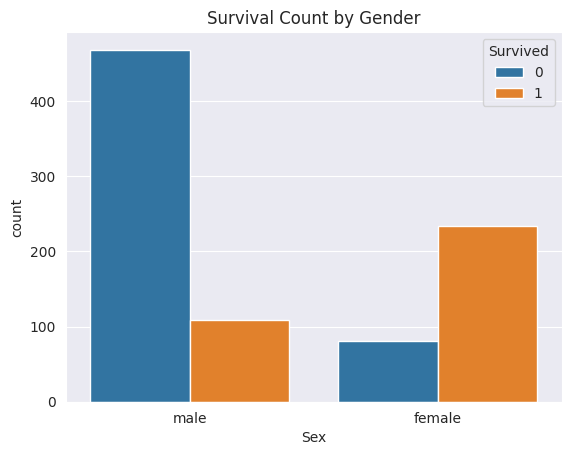

In [12]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival Count by Gender")
plt.show()

**Women** had a much higher survival rate than men, close to **74% vs around 19%**. Matches the **"women and children first"** idea.

In [13]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


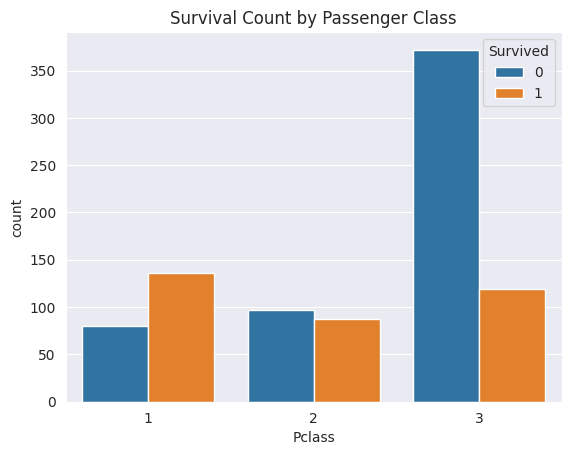

In [14]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival Count by Passenger Class")
plt.show()

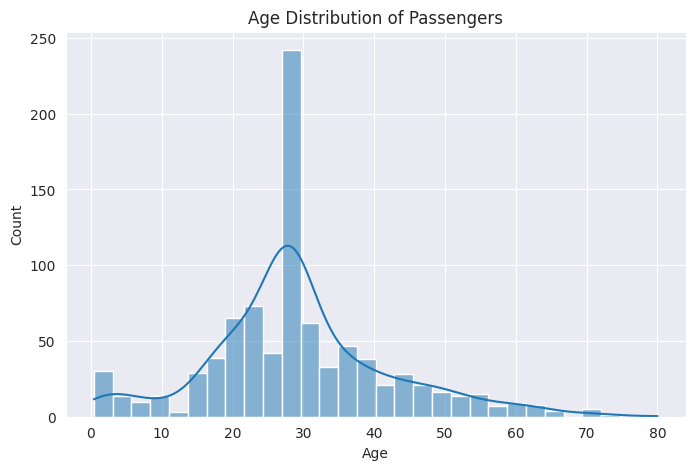

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.show()

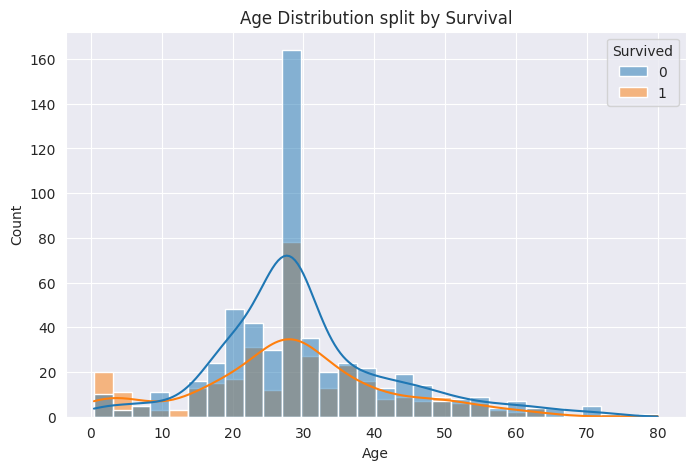

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution split by Survival")
plt.show()

In [17]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df.groupby("FamilySize")["Survived"].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


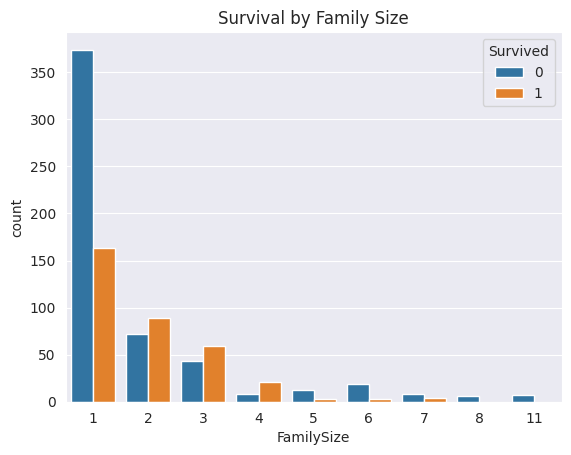

In [18]:
sns.countplot(x="FamilySize", hue="Survived", data=df)
plt.title("Survival by Family Size")
plt.show()

People traveling **alone** **or in very big families** had **lower survival rates**. **Small to medium families** (2-4 members) did better.

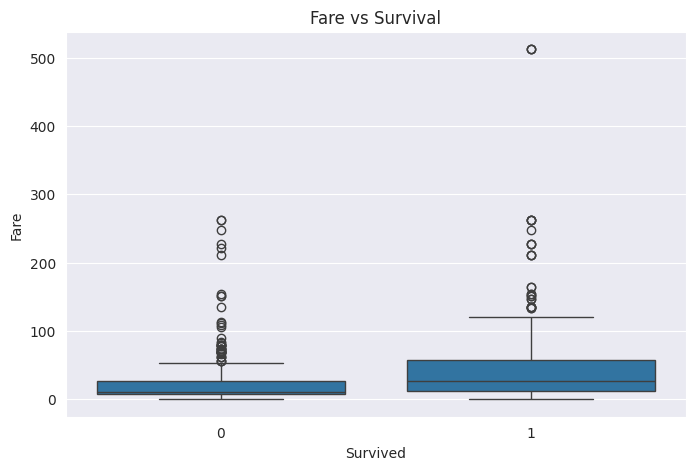

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

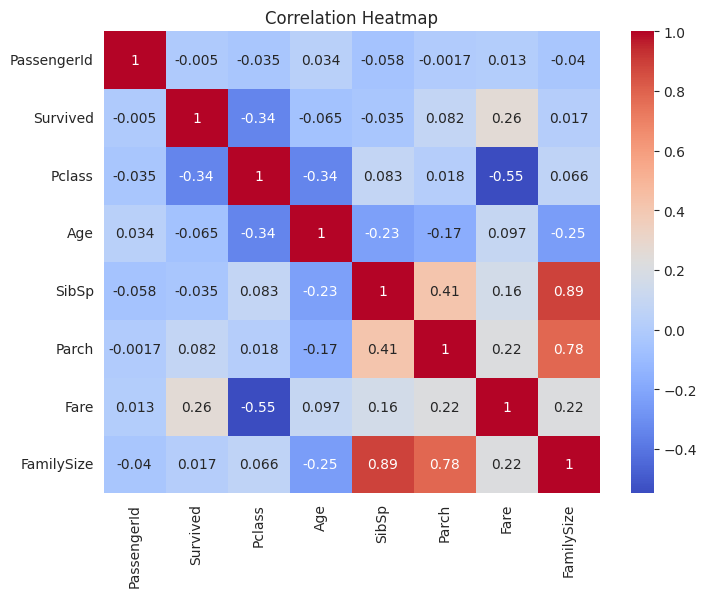

In [20]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


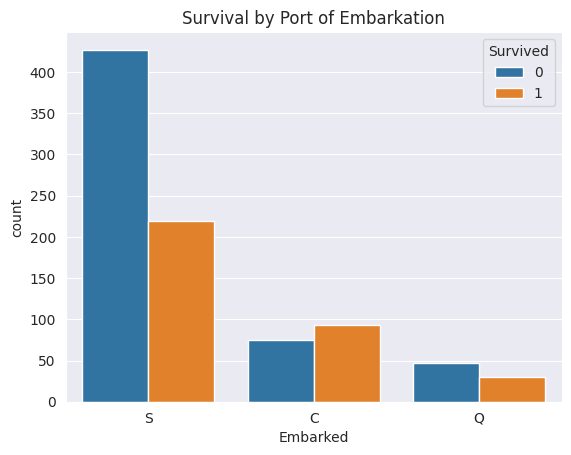

In [22]:
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Survival by Port of Embarkation")
plt.show()

Key findings from this EDA:
1. Overall survival rate was around **38%.**
2. **Gender** was the strongest factor, women survived at a much higher rate than men.
3. **Passenger class** mattered a lot, 1st class had the best survival rate, 3rd class the worst.
4. **Younger passengers**, especially children, had somewhat better survival odds.
5. Passengers who paid **higher fares** (usually 1st class) tended to survive more.
6. **Family size** small families survived more than solo travelers or very large families.
